# Pfam Domain Annotation Visualizations

This notebook loads the Pfam annotation table generated from `hmmscan` / TransDecoder and creates exploratory plots using `pandas` and `matplotlib`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

## Load Data

In [2]:
tsv_path = Path("/Users/jennyfzhao/Work/task/2026-06-03_rnaseq/papers/lymnaea_stagnalis_CNS_aging/data/annotation/pfam/protein_pfam_domains.tsv")
output_dir = tsv_path.parent / "visualizations"
output_dir.mkdir(exist_ok=True)

df = pd.read_csv(tsv_path, sep="\t")

numeric_cols = [
    "target_length",
    "protein_length",
    "full_evalue",
    "full_score",
    "domain_number",
    "domain_count",
    "domain_cevalue",
    "domain_ievalue",
    "domain_score",
    "hmm_from",
    "hmm_to",
    "ali_from",
    "ali_to",
    "env_from",
    "env_to",
    "accuracy",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,gene_id,transcript_id,protein_id,pfam_name,pfam_accession,target_length,protein_length,full_evalue,full_score,domain_number,...,domain_ievalue,domain_score,hmm_from,hmm_to,ali_from,ali_to,env_from,env_to,accuracy,description
0,MSTRG.100,MSTRG.100.1,MSTRG.100.1.p1,DEAD,PF00270.36,167,547,1.700000e-32,113.0,1,...,3.600000e-32,112.0,1,165,145,338,145,340,0.87,DEAD/DEAH box helicase
1,MSTRG.100,MSTRG.100.1,MSTRG.100.1.p1,Helicase_C,PF00271.38,110,547,9.200000e-30,103.7,1,...,2.400000e-29,102.4,2,110,377,487,376,487,0.95,Helicase conserved C-terminal domain
2,MSTRG.10002,MSTRG.10002.1,MSTRG.10002.1.p1,Glyco_hydro_59,PF02057.22,292,691,5.400000e-122,407.3,1,...,7.300000e-122,406.9,1,292,34,327,34,327,0.99,Glycosyl hydrolase family 59
3,MSTRG.10002,MSTRG.10002.2,MSTRG.10002.2.p2,Glyco_hydro_59,PF02057.22,292,333,3.100000e-95,319.5,1,...,4.500000e-95,318.9,1,235,34,270,34,278,0.98,Glycosyl hydrolase family 59
4,MSTRG.10002,MSTRG.10002.2,MSTRG.10002.2.p1,Glyco_hydro_59_C,PF21708.5,175,439,3.000000e-44,151.7,1,...,4.300000e-44,151.2,2,172,239,413,238,416,0.92,"Galactocerebrosidase, C-terminal lectin domain"


## Quick Summary

In [3]:
summary = {
    "Pfam domain rows": len(df),
    "Unique genes": df["gene_id"].nunique(),
    "Unique transcripts": df["transcript_id"].nunique(),
    "Unique proteins": df["protein_id"].nunique(),
    "Unique Pfam domains": df["pfam_name"].nunique(),
}

pd.Series(summary, name="count")

Pfam domain rows       52912
Unique genes           12695
Unique transcripts     21926
Unique proteins        22645
Unique Pfam domains     6011
Name: count, dtype: int64

In [4]:
df[[
    "gene_id",
    "protein_id",
    "pfam_name",
    "pfam_accession",
    "domain_ievalue",
    "domain_score",
    "description",
]].head(10)

,gene_id,protein_id,pfam_name,pfam_accession,domain_ievalue,domain_score,description
0,MSTRG.100,MSTRG.100.1.p1,DEAD,PF00270.36,3.600000e-32,112.0,DEAD/DEAH box helicase
1,MSTRG.100,MSTRG.100.1.p1,Helicase_C,PF00271.38,2.400000e-29,102.4,Helicase conserved C-terminal domain
2,MSTRG.10002,MSTRG.10002.1.p1,Glyco_hydro_59,PF02057.22,7.300000e-122,406.9,Glycosyl hydrolase family 59
3,MSTRG.10002,MSTRG.10002.2.p2,Glyco_hydro_59,PF02057.22,4.500000e-95,318.9,Glycosyl hydrolase family 59
4,MSTRG.10002,MSTRG.10002.2.p1,Glyco_hydro_59_C,PF21708.5,4.300000e-44,151.2,"Galactocerebrosidase, C-terminal lectin domain"
5,MSTRG.10002,MSTRG.10002.1.p1,Glyco_hydro_59_C,PF21708.5,1.100000e-43,149.9,"Galactocerebrosidase, C-terminal lectin domain"
6,MSTRG.10002,MSTRG.10002.2.p1,Glyco_hydro_59M,PF17387.9,6.300000e-43,146.2,Glycosyl hydrolase family 59 central domain
7,MSTRG.10002,MSTRG.10002.1.p1,Glyco_hydro_59M,PF17387.9,1.400000e-42,145.2,Glycosyl hydrolase family 59 central domain
8,MSTRG.10002,MSTRG.10002.2.p1,Glyco_hydro_59,PF02057.22,1.300000e-14,54.8,Glycosyl hydrolase family 59
9,MSTRG.10003,MSTRG.10003.1.p1,BNIP3,PF06553.18,2.400000e-21,76.8,BNIP3


## Plot 1: Top Pfam Domains by Frequency

This plot shows which Pfam domains appear most often among predicted proteins.

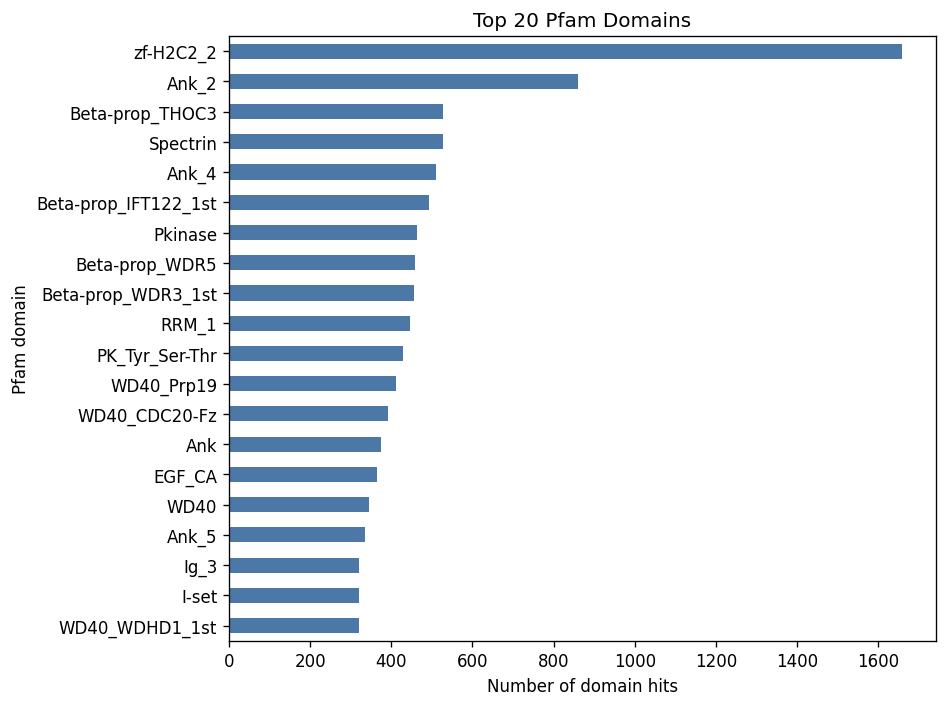

In [5]:
top_domains = df["pfam_name"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top_domains.sort_values().plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_xlabel("Number of domain hits")
ax.set_ylabel("Pfam domain")
ax.set_title("Top 20 Pfam Domains")
fig.tight_layout()
fig.savefig(output_dir / "top_20_pfam_domains.png")
plt.show()

## Plot 2: Distribution of Domain Scores

Higher domain scores generally indicate stronger Pfam matches.

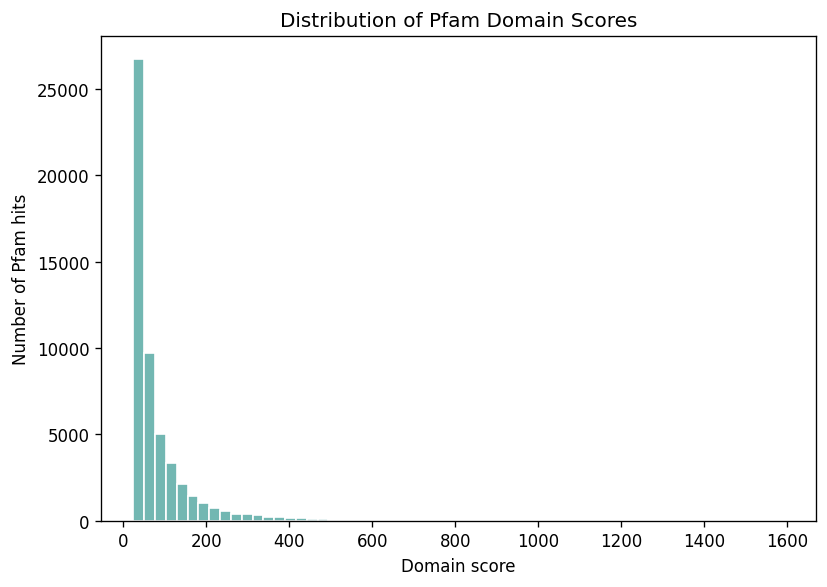

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df["domain_score"].dropna(), bins=60, color="#72b7b2", edgecolor="white")
ax.set_xlabel("Domain score")
ax.set_ylabel("Number of Pfam hits")
ax.set_title("Distribution of Pfam Domain Scores")
fig.tight_layout()
fig.savefig(output_dir / "domain_score_distribution.png")
plt.show()

## Plot 3: Distribution of Domain Significance

This transforms `domain_ievalue` into `-log10(domain i-Evalue)`, so stronger matches appear farther to the right.

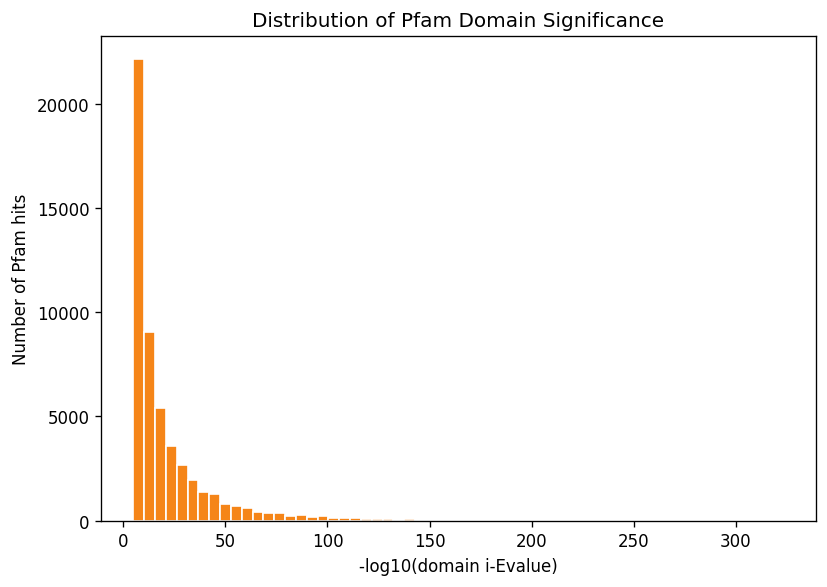

In [7]:
safe_ievalue = df["domain_ievalue"].replace(0, np.nextafter(0, 1))
df["minus_log10_ievalue"] = -np.log10(safe_ievalue)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df["minus_log10_ievalue"].dropna(), bins=60, color="#f58518", edgecolor="white")
ax.set_xlabel("-log10(domain i-Evalue)")
ax.set_ylabel("Number of Pfam hits")
ax.set_title("Distribution of Pfam Domain Significance")
fig.tight_layout()
fig.savefig(output_dir / "domain_significance_distribution.png")
plt.show()

## Plot 4: Top Genes by Number of Pfam Domain Hits

Genes with many domain hits may encode long, repetitive, or multi-domain proteins.

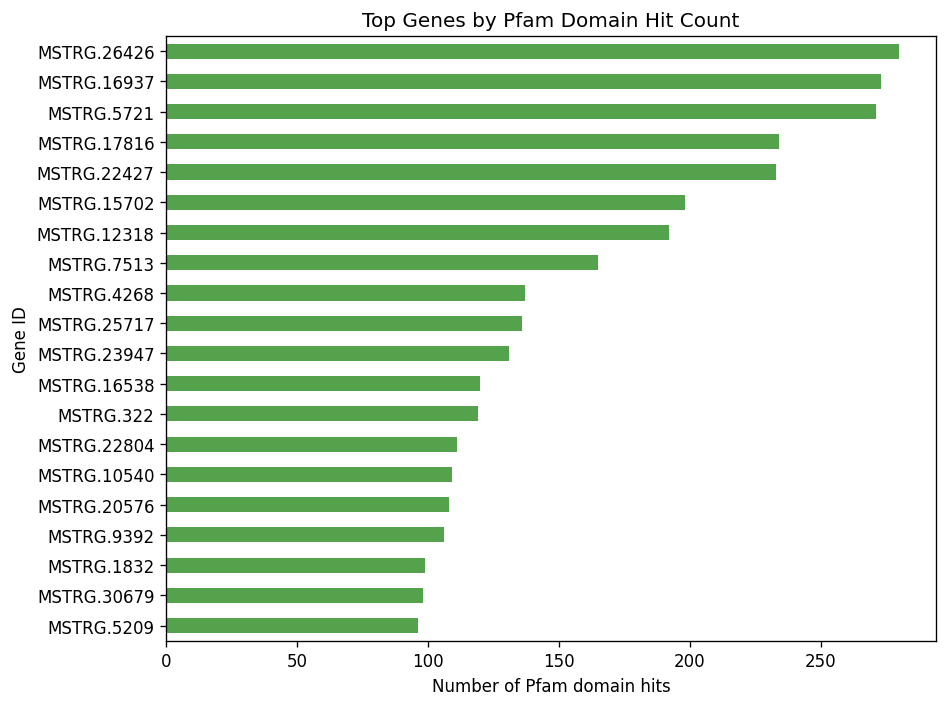

In [8]:
top_genes = df["gene_id"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top_genes.sort_values().plot(kind="barh", ax=ax, color="#54a24b")
ax.set_xlabel("Number of Pfam domain hits")
ax.set_ylabel("Gene ID")
ax.set_title("Top Genes by Pfam Domain Hit Count")
fig.tight_layout()
fig.savefig(output_dir / "top_genes_by_pfam_hit_count.png")
plt.show()

## Plot 5: Protein Length vs Domain Score

This checks whether stronger hits are concentrated in longer proteins or distributed broadly.

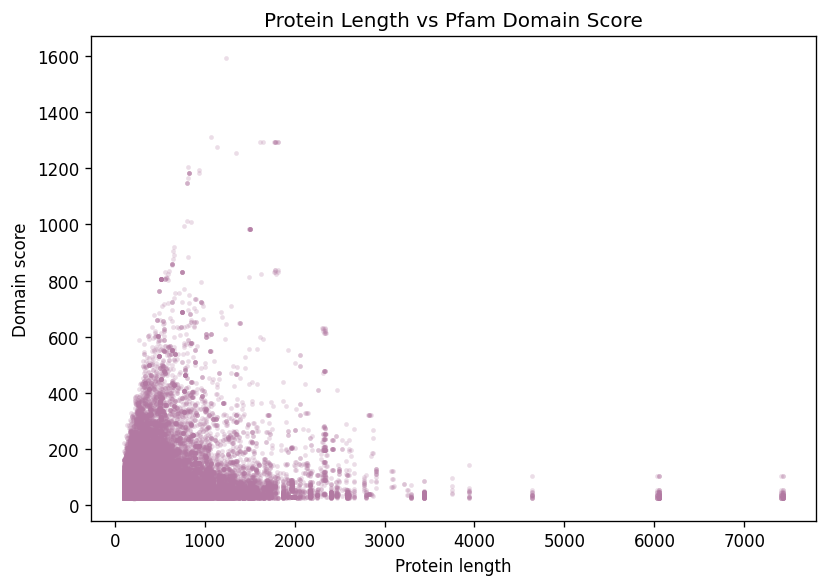

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["protein_length"], df["domain_score"], s=8, alpha=0.25, color="#b279a2", linewidths=0)
ax.set_xlabel("Protein length")
ax.set_ylabel("Domain score")
ax.set_title("Protein Length vs Pfam Domain Score")
fig.tight_layout()
fig.savefig(output_dir / "protein_length_vs_domain_score.png")
plt.show()

## Optional: Top Domain Descriptions

This table can help translate Pfam domain names into biological language.

In [10]:
top_domain_table = (
    df.groupby(["pfam_name", "pfam_accession", "description"])
    .size()
    .reset_index(name="hit_count")
    .sort_values("hit_count", ascending=False)
    .head(30)
)

top_domain_table

,pfam_name,pfam_accession,description,hit_count
5962,zf-H2C2_2,PF13465.13,Zinc-finger double domain,1659
413,Ank_2,PF12796.14,Ankyrin repeats (3 copies),861
636,Beta-prop_THOC3,PF25174.2,THOC3 beta-propeller domain,527
4874,Spectrin,PF00435.28,Spectrin repeat,527
415,Ank_4,PF13637.13,Ankyrin repeats (many copies),511
621,Beta-prop_IFT122_1st,PF23381.2,IFT122 first beta-propeller,494
3999,Pkinase,PF00069.32,Protein kinase domain,464
651,Beta-prop_WDR5,PF25175.2,WDR5 beta-propeller domain,458
648,Beta-prop_WDR3_1st,PF25173.2,WDR3 first beta-propeller domain,456
4250,RRM_1,PF00076.29,RNA recognition motif,447


In [11]:
!which python

/Users/jennyfzhao/Learning/Jupyter_Notes/.venv/bin/python
